# Configuración inicial

Iniciando...
Hecho
PATH imagen que se usa para búsqueda:  C:\Dev\PPS\Media\Images\red_car_example.jpg


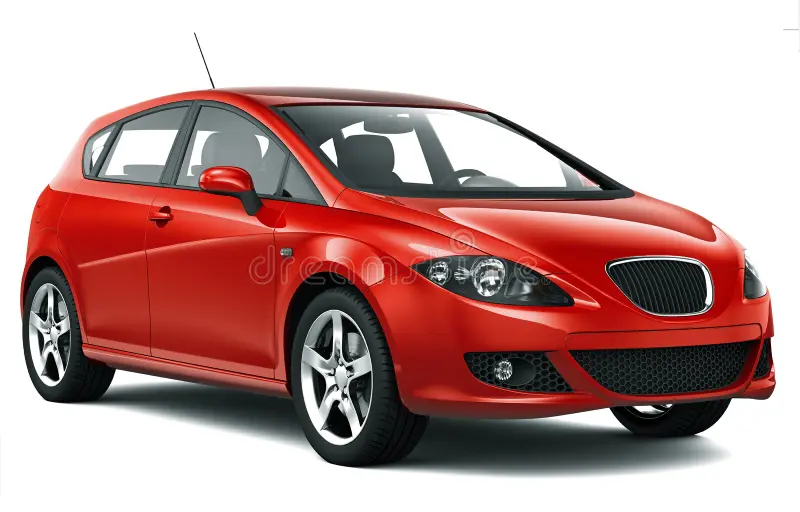

PATH imagen ejemplo del dataset:  C:\Dev\PPS\Media\Images\carsSample\1478899648276161105.jpg


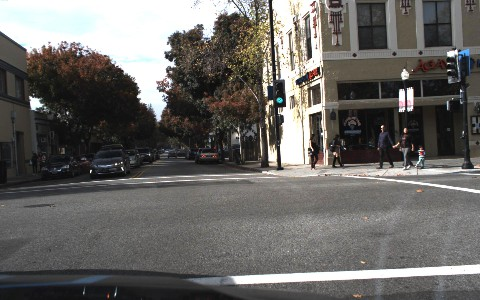

In [1]:
from image_video_detection import ImageProcessor 
import time
from IPython.display import Image as IPImage, display
import os
import PIL.Image

print("Iniciando...")
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
MEDIA_DIR = os.path.join(ROOT, "Media")
IMAGES_DIR = os.path.join(MEDIA_DIR, "Images") 
CARS_DIR = os.path.join(IMAGES_DIR, "carsSample") 
LANDSCAPES_DIR = os.path.join(MEDIA_DIR, "landscapes")

car_images_paths = [os.path.join(CARS_DIR, f) for f in os.listdir(CARS_DIR)]

PXT_DIRECTORY = "image_processor_data"
YOLOX_MODEL = "yolox_m"
CONFIDENCE_THRESHOLD = 0.25
EMBED_MODEL = 'openai/clip-vit-base-patch32'

# Instantiate ImageProcessor
images_processor = ImageProcessor(PXT_DIRECTORY,
                                  YOLOX_MODEL,
                                  CONFIDENCE_THRESHOLD,
                                  EMBED_MODEL)

print("Hecho")
search_image_path = os.path.join(IMAGES_DIR, "red_car_example.jpg")
if search_image_path and os.path.exists(search_image_path):
    print("PATH imagen que se usa para búsqueda: ", search_image_path)
    display(IPImage(filename=search_image_path, width=400))
else:
    print(f"Advertencia: La imagen de muestra no se encontró en {search_image_path}")
    
example_image_path = car_images_paths[50]
if example_image_path and os.path.exists(example_image_path):
    print("PATH imagen ejemplo del dataset: ", example_image_path)
    display(IPImage(filename=example_image_path, width=400))
else:
    print(f"Advertencia: La imagen de muestra no se encontró en {example_image_path}")

## Setup 

In [2]:
start = time.time()
print("Empezando setup del ImageProcessor...")
images_processor.setup()
end = time.time()
print(f"Setup terminado ({end - start:.2f} s)")

Empezando setup del ImageProcessor...
Connected to Pixeltable database at: postgresql+psycopg://postgres:@127.0.0.1:50291/pixeltable
Created table `image_processor_data`.
Added 0 column values with 0 errors.
Setup terminado (20.91 s)


## Carga de imágenes

In [3]:
start = time.time()
print("Empezando procesamiento de imágenes...")
images_processor.process_images(car_images_paths) 
end = time.time()
print(f"Procesamiento terminado ({end - start:.2f} s)")

Empezando procesamiento de imágenes...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Inserting rows into `image_processor_data`: 115 rows [00:31,  3.69 rows/s]
Inserted 115 rows with 0 errors.
Procesamiento terminado (74.84 s)


## Búsqueda de imágenes

Empezando búsqueda de imágenes...
Usando una imagen como query:


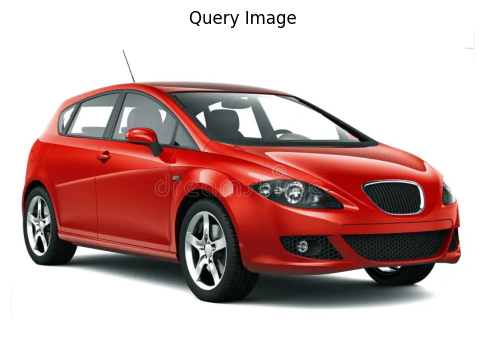


Encontrados 5 resultados para la búsqueda:


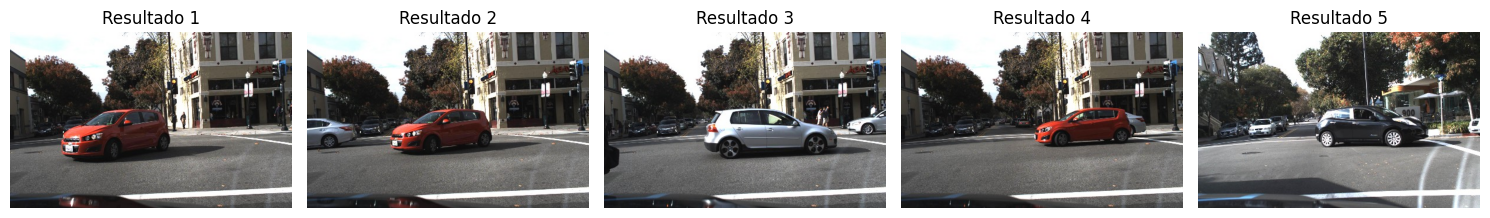

Búsqueda terminada (1.34 s)


In [4]:
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image 
import cv2 

# búsqueda texto
# text_search_query = "a person riding a scooter"
# search_type = "Text"

start = time.time()
print("Empezando búsqueda de imágenes...")

if images_processor.images_table is None or images_processor.images_table.count() == 0:
    print("No hay imágenes para buscar, cargá los datos")
    results = []
else:
    try:
        image_search_query_pil = None
        if os.path.exists(search_image_path):
            image_search_query_pil = Image.open(search_image_path)
            print("Usando una imagen como query:")
            plt.figure(figsize=(6, 4))
            plt.imshow(np.array(image_search_query_pil))
            plt.title("Query Image")
            plt.axis('off')
            plt.show()
        else:
            raise FileNotFoundError(f"Query image not found at {search_image_path}")

        # Perform the search
        search_type = "Image" # Or "Text"
        text_search_query = None # Set to a string if search_type is "Text"
        
        results = images_processor.search_image( # Using search_image
            search_type=search_type, 
            text_search_query=text_search_query,
            image_query=image_search_query_pil, # Pass the PIL image object
            limit=5
        )
                
        if results:
            print(f"\nEncontrados {len(results)} resultados para la búsqueda:")
            
            fig, axes = plt.subplots(1, len(results), figsize=(15, 5))
            if len(results) == 1:
                axes = [axes]
                
            for r_idx, result in enumerate(results):
                # For images, 'pos' is not applicable like in videos.
                # We display the image and its detections.
                img_data = result.get('image') # This should be a PIL Image object or path
                raw_detections = result.get('raw_detections')
                
                display_image = None
                if isinstance(img_data, str) and os.path.exists(img_data):
                    display_image = Image.open(img_data)
                elif isinstance(img_data, PIL.Image.Image):
                    display_image = img_data
                
                if display_image:
                    axes[r_idx].imshow(np.array(display_image))
                    axes[r_idx].set_title(f"Resultado {r_idx + 1}")
                    axes[r_idx].axis('off')
                else:
                    axes[r_idx].text(0.5, 0.5, 'No se pudo cargar la imagen', ha='center', va='center')
                    axes[r_idx].axis('off')

                # You could print raw_detections if needed
                # print(f"  Detecciones: {raw_detections}") 
            
            plt.tight_layout()
            plt.show()
        else:
            print("No se encontraron resultados para la búsqueda.")
            
    except Exception as e:
        print(f"Error en ejecución: {e}")
        results = []

end = time.time()
print(f"Búsqueda terminada ({end - start:.2f} s)")